<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [ ]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_ROOT = Path('/content/latent-ability-ml')
    if not REPO_ROOT.exists():
        subprocess.check_call([
            'git',
            'clone',
            'https://github.com/manuelfjr/latent-ability-ml.git',
            str(REPO_ROOT),
        ])

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'numpy',
        'pandas',
        'matplotlib',
        'scipy',
        'scikit-learn',
        'seaborn',
        'joblib',
        'tqdm',
        'birt-gd',
    ])

    for candidate in [REPO_ROOT, REPO_ROOT / 'notebooks', REPO_ROOT / 'utils', REPO_ROOT / 'src']:
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)

    from nb_utils import set_root
    PROJECT_ROOT = REPO_ROOT
    print(f'Running in Colab with project root: {PROJECT_ROOT}')
else:
    from nb_utils import set_root
    PROJECT_ROOT = set_root(level=2)
    print(f'Running locally with project root: {PROJECT_ROOT}')


**Environment note.** Run the next code cell first. It loads the repository and the local modules needed for this notebook, especially when opening it in Google Colab.


# Answer 2: Reading Binary IRT and 2PL Curves

This notebook provides one worked solution path for the Section 2 activity.


## Activity Goals

By the end of this notebook, you should be able to:

- create a small binary IRT item bank;
- manipulate difficulty and discrimination values;
- inspect how ICCs change when item parameters change;
- interpret what different curve shapes mean in practice.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.handson import binary_irt_probability, plot_binary_iccs


## Task 1

Create your own item bank with three items:

- one easy item,
- one medium item,
- one hard item.

Give them different discrimination values.


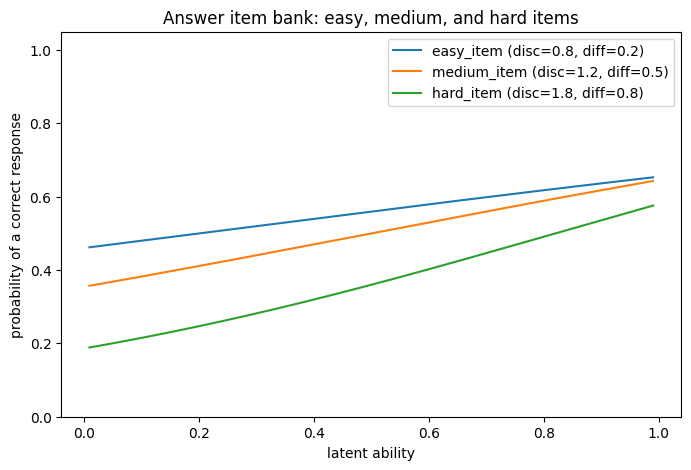

,item,difficulty,discrimination
0,easy_item,0.20,0.8
1,medium_item,0.50,1.2
2,hard_item,0.82,1.8


In [3]:
item_bank = pd.DataFrame(
    [
        {'item': 'easy_item', 'difficulty': 0.20, 'discrimination': 0.80},
        {'item': 'medium_item', 'difficulty': 0.50, 'discrimination': 1.20},
        {'item': 'hard_item', 'difficulty': 0.82, 'discrimination': 1.80},
    ]
)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
plot_binary_iccs(item_bank=item_bank, ax=ax, title='Answer item bank: easy, medium, and hard items')
plt.show()

item_bank


## Task 2

Compute the probability of success for three respondents with abilities `0.2`, `0.6`, and `1` and discurss about the output.


In [4]:
abilities = np.array([0.2, 0.6, 1.0])

probability_table = pd.DataFrame(
    {
        'item': item_bank['item'],
        'difficulty': item_bank['difficulty'],
        'discrimination': item_bank['discrimination'],
        'P(theta=0.2)': [binary_irt_probability(0.2, row.difficulty, row.discrimination) for row in item_bank.itertuples()],
        'P(theta=0.6)': [binary_irt_probability(0.6, row.difficulty, row.discrimination) for row in item_bank.itertuples()],
        'P(theta=1.0)': [binary_irt_probability(1.0, row.difficulty, row.discrimination) for row in item_bank.itertuples()],
    }
)

probability_table


,item,difficulty,discrimination,P(theta=0.2),P(theta=0.6),P(theta=1.0)
0,easy_item,0.20,0.8,0.500000,0.579324,0.654753
1,medium_item,0.50,1.2,0.410960,0.529964,0.645656
2,hard_item,0.82,1.8,0.246754,0.402274,0.580299


## Task 3

Make one item have **negative discrimination** and inspect the curve. In a teaching discussion, how would you interpret that behavior?


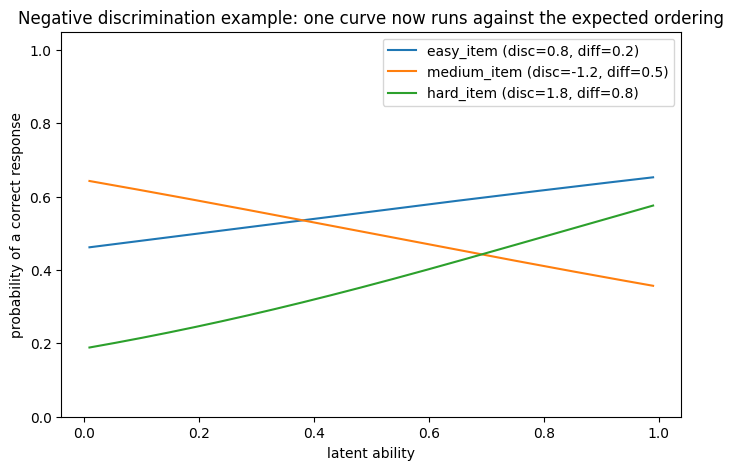

,item,difficulty,discrimination
0,easy_item,0.20,0.8
1,medium_item,0.50,-1.2
2,hard_item,0.82,1.8


In [5]:
negative_item_bank = item_bank.copy()
negative_item_bank.loc[negative_item_bank['item'] == 'medium_item', 'discrimination'] = -1.20

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
plot_binary_iccs(
    item_bank=negative_item_bank,
    ax=ax,
    title='Negative discrimination example: one curve now runs against the expected ordering',
)
plt.show()

negative_item_bank


## Reflection Questions

1. Which item best separates medium and high ability?
2. Which item is easiest for low-ability respondents?
3. What does a negative discrimination suggest about an item?
4. Why can ICCs be more informative than average accuracy alone?
